## Generate and Save IIR Filters

This example uses bias T connected between I1 Qblox and channel 1 of the LeCroy Wavepro 715Zi.

In [1]:
#sys.path is used to access predistort.py in parent directory
import sys, os
sys.path.append(os.path.dirname(os.path.abspath("")))
import predistort

import json
from qblox_instruments import Cluster
from qblox_instruments.types import InstrumentType

from instrumentLeCroy import InstrumentLeCroy
from instrumentQblox import InstrumentQblox

print(predistort.__doc__)



predistort.py

Handles the generation and testing of infinite impulse reponse (IIR) filters
which are used to correct for the signal distortion caused by an electical system.
To preform the correction, a square pulse is sent through the system and the response is
measured. An exponential decay function is then fit to the response, to extract function parameters.
By taking the reciprocal of the Laplace transform of the decay function, we get the inverse transfer function.
The bilinear transform of the transfer function is taken next to determine filter coefficients a1, b0, b1,
of the IIR filter. This approach is then iterated on until the output of the system procduces the ideal signal
of a flat square pulse. The filter coefficents can then be applied to an arbitrary pulse to correct for distortions.

Note: The load impedance connected to the bias tee is extremely important to consider because it can alter the time constant of the circuit.
In our testing, this was the primary cause of 

#### Connect and Configure Qblox Cluster

In [2]:
#Scan for clusters
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.6.2 with name "cluster-mm" and serial number 00015_2251_003


In [3]:
#Connect to the Qblox cluster
cluster = Cluster("cluster_mm", "192.168.137.2")

qblox = InstrumentQblox(cluster, InstrumentType.QRM, 1e9, 100)
#Configure Qblox
#predistort.configureHardware(cluster, InstrumentType.QRM, samplePeriodAwg=1e-9, acquisitionAvgCount=100)

#### Generate Filters

In [4]:
pulseDuration = 16000 #Nanoseconds
numIterations = 3 	  #Generate 10 filters

#Since curveFitBounds is less than numIterations
#The remaining iterations use the bounds (300, 3700)
#The same idea is used if you were to specify a paramGuessList
curveFitBounds = [
	(10000, 15000),
	(2000, 15000),
]

paramGuessList = [(0.5, -1, 1e-4),
				  (0.3, 1, 5e-4),
				  (0.3, 1, 5e-4)]

#leCroy = InstrumentLeCroy("GPIB0::8::INSTR", timeDiv=1e4, totalSampleCount=10000,
#					numSweeps=200, triggerLevel=0.05)

iterationData = predistort.iterativeIIRFiltering(numIterations = numIterations, curveFitBounds=curveFitBounds,
												  pulseDuration=pulseDuration, acqInstr=qblox,
												    outInstr=qblox, paramGuessList=paramGuessList, reductionFactor=1)

#Plot all of the iteration data, or iterationData can be directly used for custom plotting
#predistort.plotFilterIterations(iterationData, pulseDuration, 1e-9)

#Save the iteration data to a JSON file for later use.
shouldSaveFile = True
fileName = "1MOhmFilterData.json"

if shouldSaveFile:
	with open(fileName, "w", encoding="utf-8") as file:
		json.dump(iterationData, file, indent=4)
		file.close()



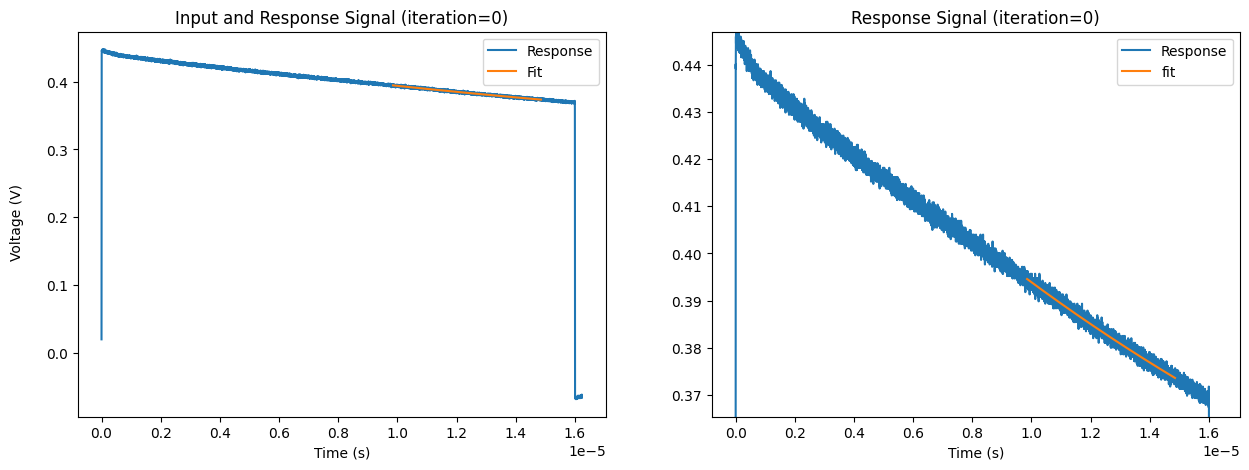

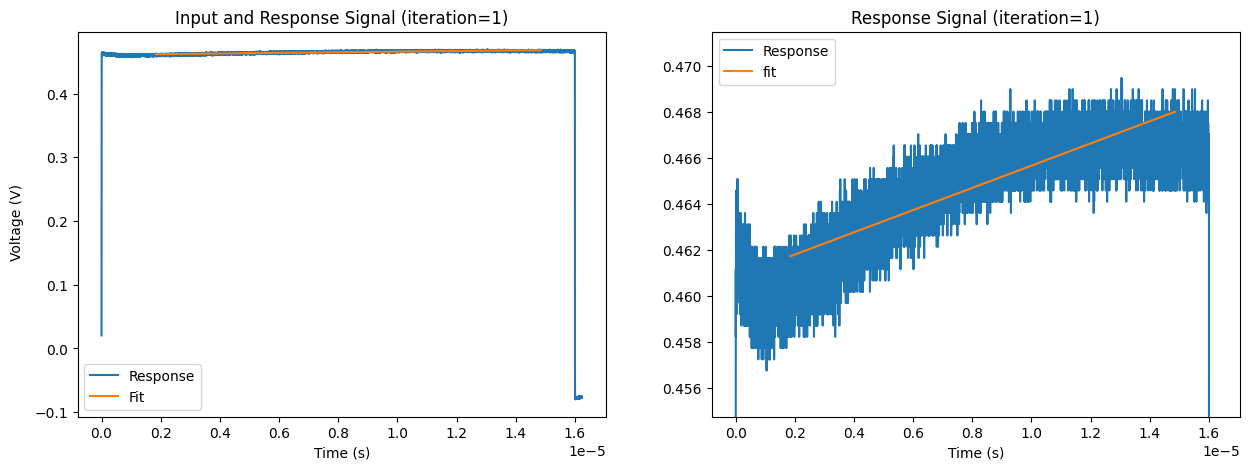

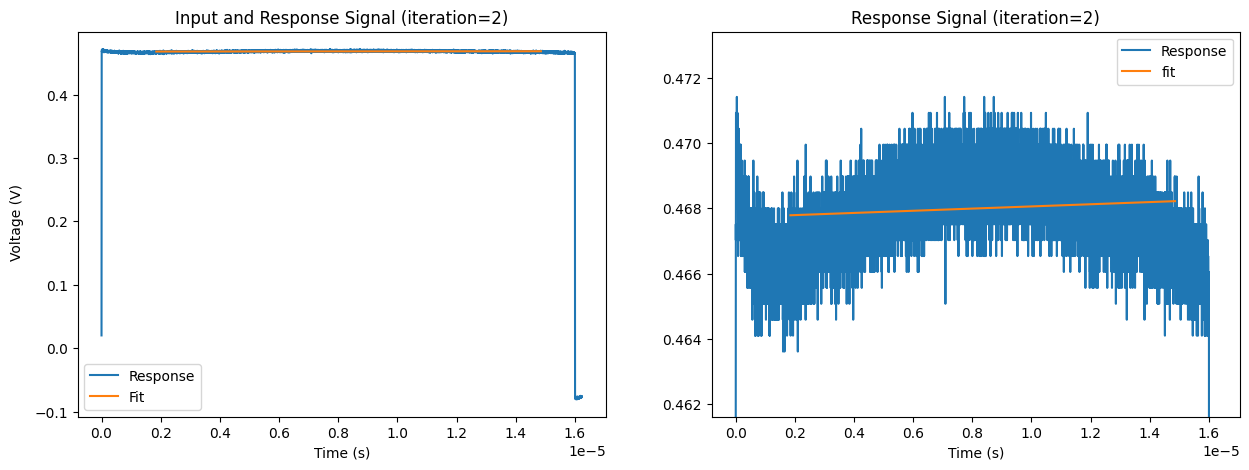

In [5]:
import matplotlib.pyplot as plt	

predistort.plotFilterIterations(iterationData, pulseDuration, 1/qblox.acqSamplingRate)

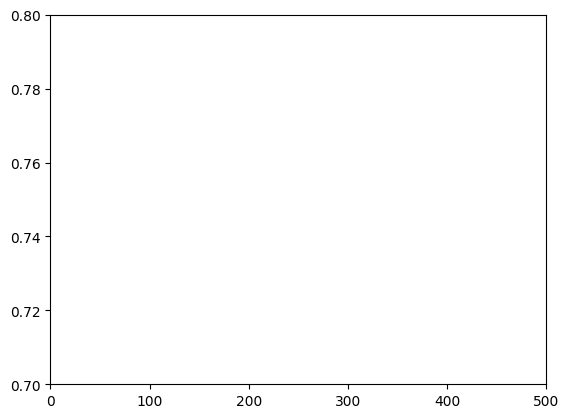

In [6]:
plt.plot(iterationData[0]["response"])
plt.plot(iterationData[0]["curveFitX"], iterationData[0]["curveFitY"], color = 'orange')
plt.xlim(0, 500)
plt.ylim(0.7, 0.8)
plt.show()